In [1]:
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,confusion_matrix


## Data Preprocessing

In [2]:
# Loading the dataset
data = load_breast_cancer()
X = pd.DataFrame(data=data["data"],columns=data["feature_names"])
Y = data["target"]

In [3]:
# Splitting the dataset
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size = 0.3)

## Training

In [4]:
# Training the model with a depth of max 15
# ccp_alpha is an algorithm to prune excess nodes of a tree
model = DecisionTreeClassifier(ccp_alpha=0.01)
model.fit(X_train,Y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


## Prediction

In [5]:
# Predicing values
# 0 = Malignant | 1 = Benign 
Y_pred = model.predict(X_test)
Y_pred

array([1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0,
       1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0,
       0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1,
       1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1])

## Evaluation

In [6]:
# Acuraccy of the model
accuracy_score(Y_test,Y_pred)*100

92.39766081871345

In [7]:
# '0' predicted - '60' correct , '3' wrong
# '1' predicted - '105' correct , '3' wrong
confusion_matrix(Y_test,Y_pred,labels=[0,1])

array([[ 55,   5],
       [  8, 103]], dtype=int64)

In [8]:
# Which feature / comuns were more importnt to the modle while training
model.feature_importances_

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.03549811, 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.12142656, 0.        ,
       0.        , 0.        , 0.84307532, 0.        , 0.        ])

In [9]:
# Dataframe of important features
imp_features = pd.DataFrame((model.feature_importances_)*100,index=data["feature_names"],columns=["Percent"])
display(imp_features[imp_features["Percent"]>0]) 


,Percent
mean concave points,3.549811
worst area,12.142656
worst concave points,84.307532


## Graph Plotting

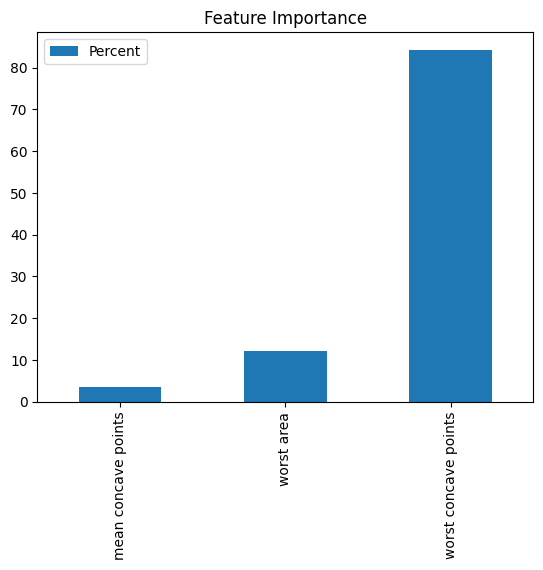

In [10]:
# Important featuers graph
_ = imp_features[imp_features["Percent"]>0].plot(kind='bar',title='Feature Importance')

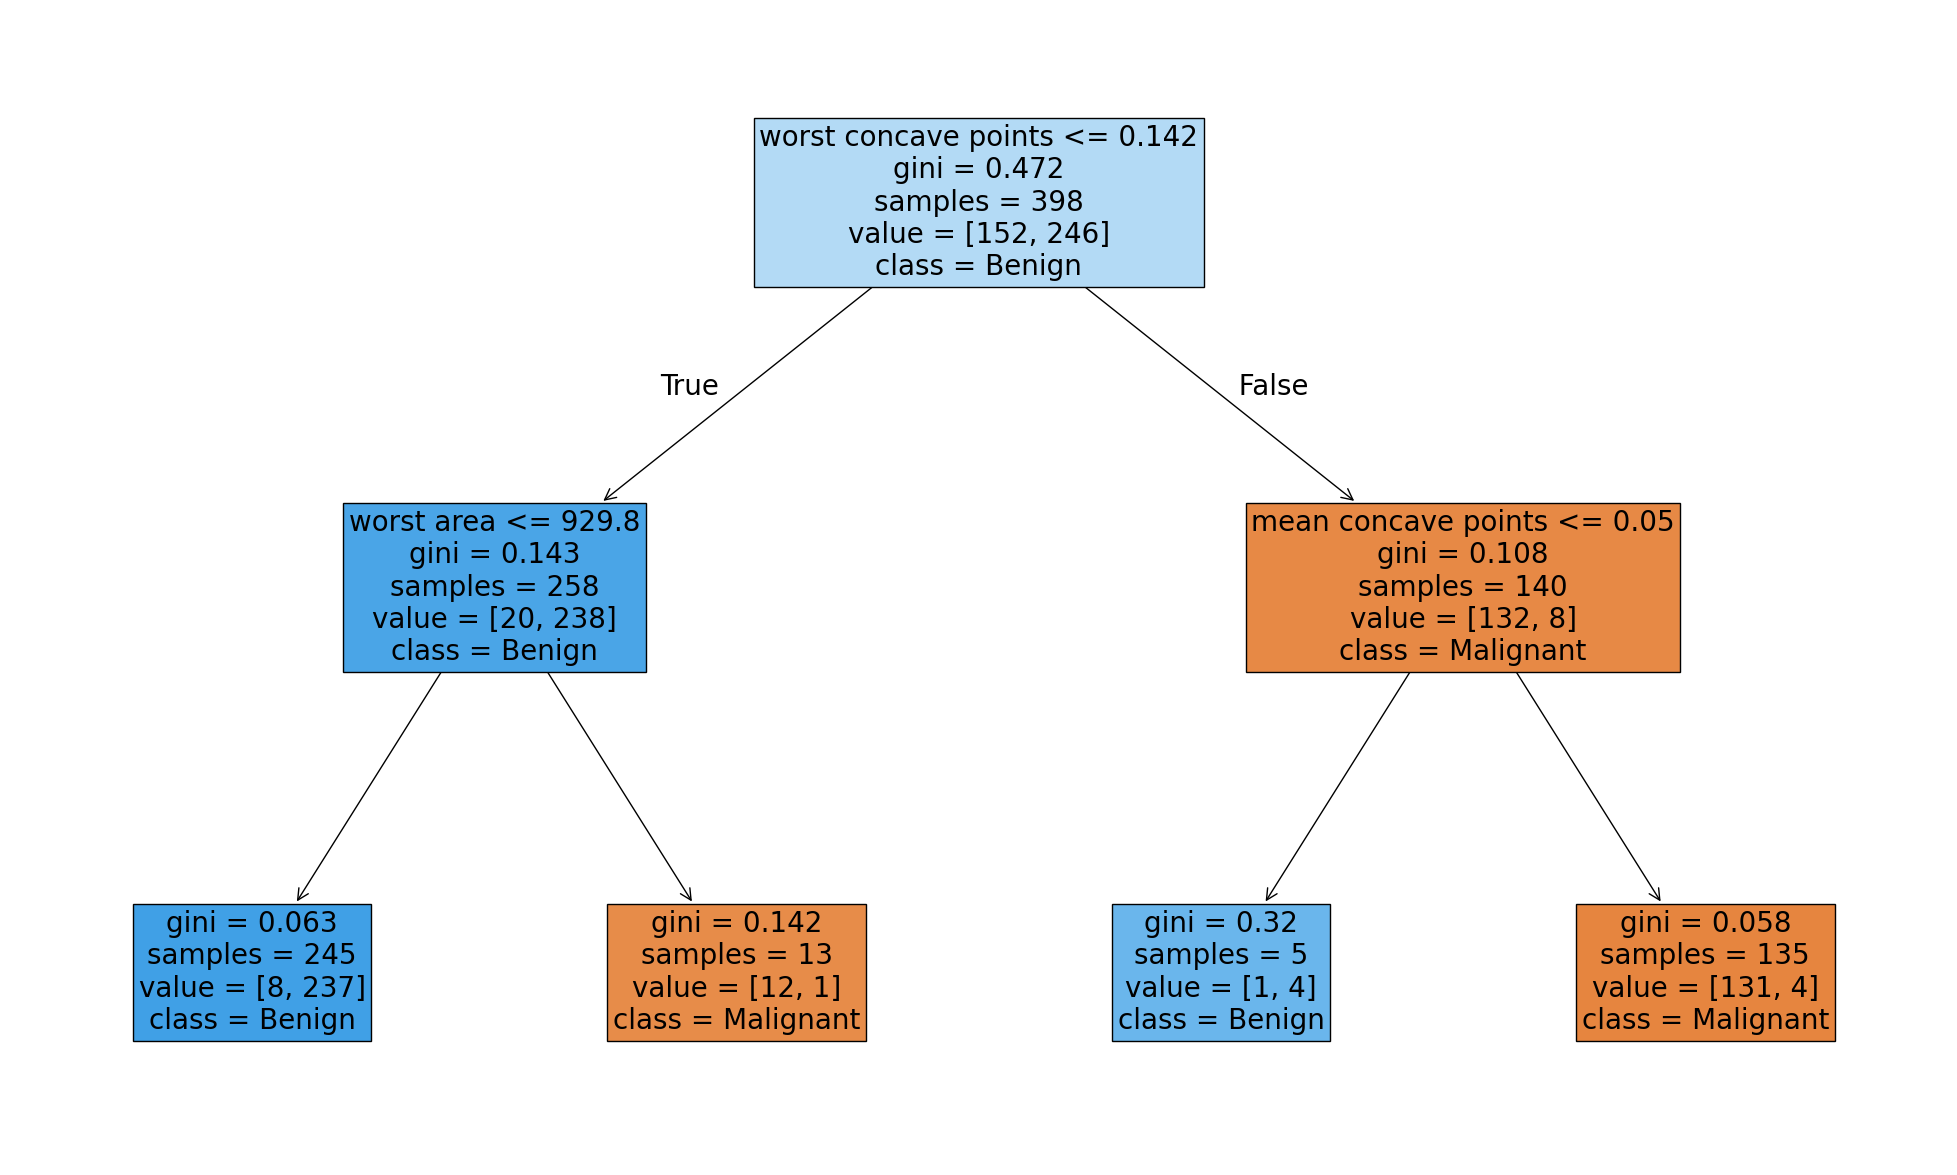

In [12]:
from sklearn import tree
from matplotlib import pyplot as plt
fig = plt.figure(figsize=(25,15))
_ = tree.plot_tree(model,feature_names=data.feature_names,
               class_names={0:"Malignant",1:'Benign'},
               filled=True,fontsize=20)